# 04 — Real data: NGC 5102 HST/STIS galactic center

This notebook fits a spectrum of NGC 5102 from the Hubble Space Telescope using the
STIS spectrograph (G750L grating).  The STIS data has higher spatial resolution than
MUSE (~0.1 arcsec per bin vs ~0.2 arcsec), which probes kinematics at smaller radii.

The spectrum used here (`bin0105sp.spec`) is a spatial bin from the inner region of
the galaxy.  The data is bundled in `examples/data/stis/`.

**Key differences from the MUSE notebook:**
- Shorter wavelength range (8275 – 8846 Å, step = 0.5586 Å/pixel)
- The file's error column is a placeholder, not real per-pixel errors — we override
  it with a uniform S/N-based estimate (`gal_errors=flux/50`), same approach as the
  MUSE notebook, rather than using `use_spectrum_errors=True`
- Templates are CaT stellar library scans (Cenarro et al. 2001)
- `wavemin_full` and `step` must be provided because the spectrum file uses integer pixel indices

In [ ]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit
from kinextract.fitting import fit_losvd_gauss_hermite

plt.style.use('kinextract.mplstyle')

# Path to bundled example data (adjust if running from a different location)
DATA_DIR = Path('..') / 'data'
STIS_DIR = DATA_DIR / 'stis'

# ── To use a different spectrum, change this line ────────────────────────────
SPEC_FILE = STIS_DIR / 'bin0105sp.spec'

## 1. Load and inspect the spectrum

In [2]:
# ── STIS wavelength grid ──────────────────────────────────────────────────────
# The .spec file contains integer pixel indices (1–1024); kinextract reconstructs
# wavelengths as: wave = wavemin_full + (pix - 1) * step
WAVEMIN_FULL = 8275.0       # Å, pixel 1
STEP         = 0.5586       # Å / pixel  (mean STIS G750L dispersion)
N_PIX        = 1024
wavelength   = WAVEMIN_FULL + np.arange(N_PIX) * STEP   # observed frame

data = np.loadtxt(SPEC_FILE)
pix, flux = data[:, 0].astype(int), data[:, 1]

# This STIS spectrum just has placeholder error values, 
# so we can use a simple S/N estimate to set the errors instead
snr = 50.0
ferr = (flux / snr) + 1e-3  # counts, avoid zero error

print(f"Spectrum pixels: {len(flux)}")
print(f"Flux range:  {flux.min():.0f} - {flux.max():.0f}  counts")
print(f"Error range: {ferr.min():.0f} - {ferr.max():.0f}  counts")
print(f"Median S/N per pixel: {np.median(flux / ferr):.1f}")

Spectrum pixels: 1024
Flux range:  0 - 12996374  counts
Error range: 0 - 259927  counts
Median S/N per pixel: 50.0


## 2. Quick-look plot

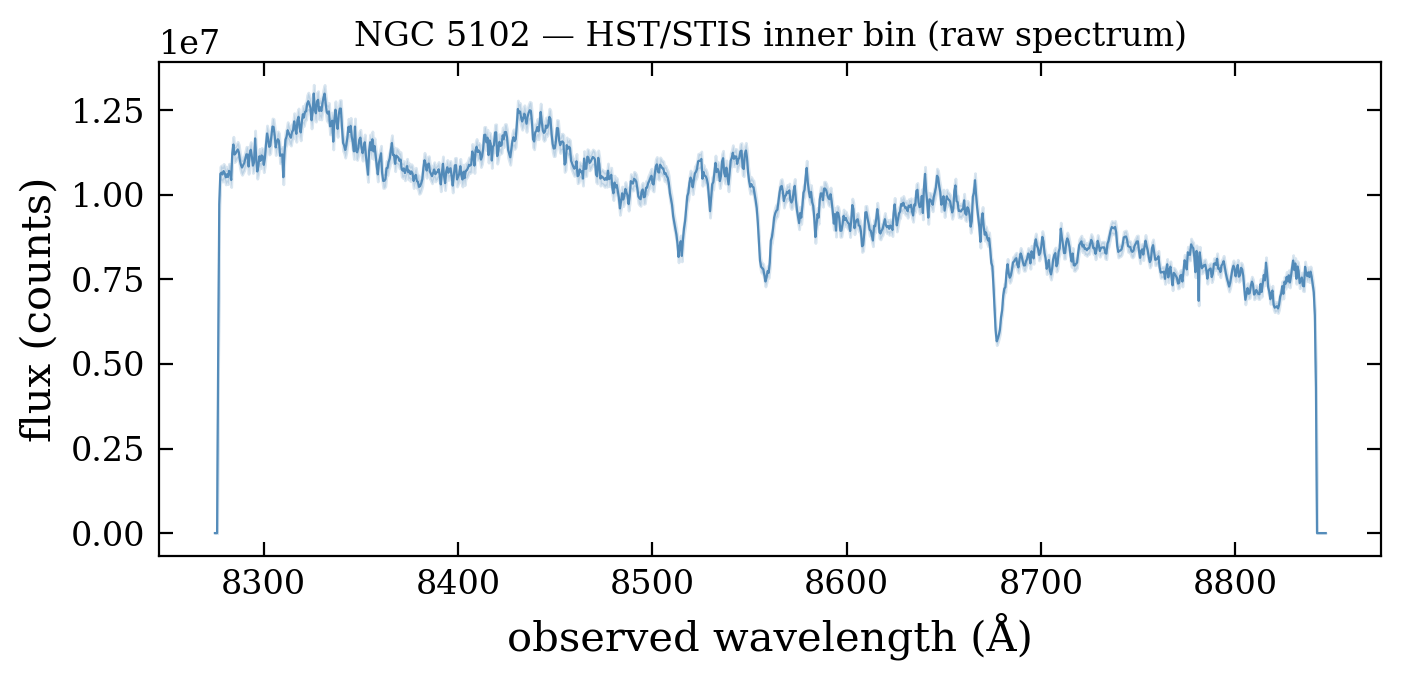

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(wavelength, flux, lw=0.8, color='steelblue', alpha=0.9)
ax.fill_between(wavelength, flux - ferr, flux + ferr, color='steelblue', alpha=0.2)
ax.set_xlabel('observed wavelength (Å)')
ax.set_ylabel('flux (counts)')
ax.set_title('NGC 5102 — HST/STIS inner bin (raw spectrum)')
plt.tight_layout()
plt.show()

## 3. FitConfig for STIS

Because column 0 of the `.spec` file contains integer pixel indices, kinextract
needs `wavemin_full` and `step` to reconstruct the wavelength axis.

The file's own error column is just a placeholder, so we pass the S/N-based `ferr`
computed above directly via `gal_errors=` (overriding the file column) and set
`use_spectrum_errors=False` since we're not using the file's errors either way.

In [4]:
tmpdir = Path(tempfile.mkdtemp(prefix='kinextract_stis_'))

cfg = FitConfig(
    template_list_file    = str(STIS_DIR / 'Tlist'),
    template_dir          = str(STIS_DIR),
    outdir                = str(tmpdir),
    wavemin_full          = WAVEMIN_FULL,  # Å, minimum wavelength of full spectrum (pixel 1)
    step                  = STEP,          # Å / pixel
    wavefitmin            = 8400.0,        # Å  (rest-frame; kinextract applies zgal)
    wavefitmax            = 8750.0,        # Å
    zgal                  = 0.001556,      # redshift estimate from NED (heliocentric)
    losvd_vmin            = -300.0,        # km/s
    losvd_vmax            = +300.0,        # km/s
    fit_als_continuum     = True,
    als_optimize          = True,          # Optimize ALS hyperparameters (λ, p) using BIC
    als_use_bic           = True,
    als_bic_dof_penalty   = 2.0,           # BIC penalty factor for LOSVD degrees of freedom
    use_spectrum_errors   = False,         # per-pixel errors not available
    xlam_auto             = True,
    xlam_criterion        = 'roughness',   # Allows us to control how smooth the LOSVD is; 'roughness' is a good default for real data
    xlam_smooth_threshold = 0.25,          # Controls how smooth the LOSVD is; smaller = smoother. Default is 0.25.
    sigl                  = 100.0,
    clean                 = True,
    clean_ca_half_width   = 8.0,
    map_maxiter           = 2000,
    print_every           = 10000,
)
print("FitConfig ready.")

FitConfig ready.


## 4. Run the fit

In [ ]:
fit = run_spectral_fit(cfg, gal_file=str(SPEC_FILE), gal_errors=ferr)
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chi2_red = {out['chi2_red']:.3f}")
print(f"xlam used = {st.xlam}")

In [ ]:
from IPython.display import display, Math

display(Math(fr"\chi^2_{{\rm red}} = {out['chi2_red']:.3f}"))

## 5. Gauss-Hermite moments

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"V  = {gh['vherm']:+.1f} km/s")
print(f"σ  = {gh['sherm']:.1f} km/s")
print(f"h3 = {gh['h3']:+.4f}")
print(f"h4 = {gh['h4']:+.4f}")

V  = +15.5 km/s
σ  = 66.8 km/s
h3 = +0.1362
h4 = +0.0259


## 6. Results plots

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('NGC 5102 — STIS central bin', fontsize=13)

# ── Panel 1: spectral fit ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.fill_between(st.x, st.g - st.gerr, st.g + st.gerr, alpha=0.20, color='gray', label=r'$1\sigma$ error')
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax.set_ylim(0.9*st.g.min(), 1.1*st.g.max())
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.6)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'$\lambda_{\mathrm{rest}}$ ($\mathrm{\AA}$)')
ax.set_ylabel('normalised flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
b_norm = b / trapezoid(b, st.xl)
ax.plot(st.xl, b_norm, lw=2.0, color='black', label='recovered LOSVD')
ax.plot(st.xl, gh['model']/trapezoid(gh['model'], st.xl), lw=1.5, color='tomato', ls='--', label='Gauss-Hermite fit')
ax.axvline(gh['vherm'], lw=1.0, color='tomato', ls=':')
ax.axvline(0,           lw=0.8, color='grey',   ls='--', alpha=0.6)
ax.text(0.77, 0.79,
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s\n"
        f"h3 = {gh['h3']:+.4f}\n"
        f"h4 = {gh['h4']:+.4f}",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Recovered LOSVD — NGC 5102 centre')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

## 7. Error estimation

Uncertainty on the LOSVD is estimated two ways:

- **Laplace covariance**: Gaussian approximation at the MAP solution — fast, analytical, reliable for Gaussian LOSVDs.
- **Residual bootstrap**: Resamples fit residuals to generate synthetic spectra and re-fits each → non-parametric; preferred for publication uncertainties.

In [11]:
from kinextract import LOSVDErrorEstimator

N_BOOT = 50   # increase to ≥200 for publication

est     = LOSVDErrorEstimator(fit, cfg)
laplace = est.laplace_covariance()
boot    = est.residual_bootstrap(n_bootstrap=N_BOOT, n_jobs=1)
summary = est.summarize(laplace_result=laplace, bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Kinematic moments (bootstrap uncertainties):")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Computing Hessian...
[LOSVDErrors] Using JAX gradient-backed Hessian FD (CPU)
[LOSVDErrors] Laplace covariance done in 0.4s. Hessian PD (free params): True. Pinned: 5/29 LOSVD bins, 1/1 template weights. Max projected |grad|: 0.19
[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=1)...
[     4.39s] Ca II mask shift: +1.880 Å  (als_mask_center_shift_A → 4.186 Å)
[     4.39s] ALS absorption-clean iter 1: sigma=1.22, rejected=69, base_pixels=318
[     4.39s] ALS absorption-clean iter 2: sigma=1.235, rejected=0, base_pixels=318
[     4.39s] ALS init: lam=1.000e+03 p=0.5 median=9.875e+06 base_pixels=318 line_mask_pixels=85
[     4.39s] ALS outer iteration 1/4
[     4.39s]   protecting Ca II [8490.9, 8513.5] npix=40
[     4.39s]   protecting Ca II [8534.9, 8557.7] npix=41
[     4.39s]   protecting Ca II [8654.8, 8677.9] npix=42
[     4.39s] Cleaning protection: 123 pixels
[     4.39s] START MAP clean iter 1


/var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/ipykernel_54607/474528249.py:6: RuntimeWarning: Laplace covariance: the largest projected gradient component at the MAP solution is 0.19, above grad_warn_threshold=0.05. This suggests the MAP optimization did not fully converge, which can make the Hessian indefinite and the resulting error bars unreliable (some may be silently near-zero). Consider tightening map_ftol/map_gtol or enabling use_jax_objective before re-fitting.
  laplace = est.laplace_covariance()


[     4.48s] END   MAP clean iter 1 (0.09s)
[     4.48s] Clean iter 1: masked 3 pixels (sigma=1.37)
[     4.48s] START MAP clean iter 2
[     4.66s] END   MAP clean iter 2 (0.18s)
[     4.66s] Clean iter 2: masked 1 pixels (sigma=1.34)
[     4.66s] START MAP clean iter 3
[     4.75s] END   MAP clean iter 3 (0.10s)
[     4.76s] Clean converged after 3 iter.
[     4.76s] ALS absorption-clean iter 1: sigma=1.117, rejected=69, base_pixels=314
[     4.76s] ALS absorption-clean iter 2: sigma=1.095, rejected=0, base_pixels=314
[     4.76s]   ALS update: lam=1.000e+03 p=0.5 delta=0.009597 base_pixels=314 line_mask_pixels=85
[     4.76s]   ALS continuum median fractional change = 0.009597
[     4.76s] ALS outer iteration 2/4
[     4.76s] START MAP optimize ALS outer 2
[     4.91s] END   MAP optimize ALS outer 2 (0.15s)
[     4.92s] ALS absorption-clean iter 1: sigma=1.107, rejected=69, base_pixels=314
[     4.92s] ALS absorption-clean iter 2: sigma=1.08, rejected=0, base_pixels=314
[     4.92s]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('NGC 5102 — STIS galactic center error estimation', fontsize=13)

b_trap = trapezoid(b, st.xl)
b_map  = b / b_trap

bs       = np.array(boot['b_samples'])
bs_traps = np.array([trapezoid(s, st.xl) for s in bs])[:, np.newaxis]
bs       = bs / bs_traps
b_median = np.median(bs, axis=0)
b_lo     = np.maximum(np.percentile(bs, 16, axis=0), 0.0)
b_hi     = np.percentile(bs, 84, axis=0)
gh_med   = fit_losvd_gauss_hermite(st.xl, b_median, fit_h3h4=True)

# Panel 1: Laplace
ax = axes[0]
b_sig  = laplace['b_err'] / b_trap
b_lo_l = np.maximum(b_map - b_sig, 0.0)   # LOSVD >= 0 everywhere
ax.plot(st.xl, b_map, lw=1.0, ls=':', color='steelblue', alpha=0.8, label='MAP fit')
ax.fill_between(st.xl, b_lo_l, b_map + b_sig,
                alpha=0.35, color='steelblue', label=r'$\pm 1\sigma$ Laplace')

ax.text(0.73, 0.79,
        "Recovered:\n"
        fr"V   = {gh_map['vherm']:+.1f} $\pm$ {laplace['gh_err']['gh_vherm']:.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_map['sherm']:.1f} $\pm$ {laplace['gh_err']['gh_sherm']:.1f}" + " km/s\n"
        fr"$h3$ = {gh_map['h3']:+.4f} $\pm$ {laplace['gh_err']['gh_h3']:.4f}" + "\n"
        fr"$h4$ = {gh_map['h4']:+.4f} $\pm$ {laplace['gh_err']['gh_h4']:.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Laplace covariance')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

# Panel 2: Bootstrap
ax = axes[1]
ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap 16-84th pct  (n={N_BOOT})')
ax.plot(st.xl, b_median, lw=2.0, color='tomato', zorder=5, label='bootstrap median')


ax.text(0.73, 0.79,
        f"Recovered:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'Bootstrap (n={N_BOOT})')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()